### 1. Nhập các thư viện

In [1]:
!pip install underthesea -q
!pip install fasttext -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, vstack, csr_matrix
from lightgbm import LGBMClassifier
import fasttext
import warnings
warnings.filterwarnings('ignore')


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Đọc dữ liệu

In [4]:
root_path = "/content/drive/MyDrive/NCKH/"

labeled_df = pd.read_csv(root_path + "Pseudo_labeling/labeled_db.csv") # file có nhãn
merged_df = pd.read_csv(root_path + "Processing/merged_df.csv") # toàn bộ comment

# Tách dữ liệu chưa có nhãn
unlabeled_df = merged_df[
    ~merged_df["comment_id"].isin(labeled_df["comment_id"])
].copy()

print("Merged:    ", merged_df.shape)
print("Labeled:   ", labeled_df.shape)
print("Unlabeled: ", unlabeled_df.shape)


Merged:     (320682, 22)
Labeled:    (32068, 26)
Unlabeled:  (288614, 22)


### 3. Tải FastText pre-trained

In [5]:
### # Tải FastText tiếng Việt pre-trained (cc.vi.300.bin ~4GB) (Nếu chưa có)
# import urllib.request
# urllib.request.urlretrieve(
#     "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.bin.gz",
#     root_path + "cc.vi.300.bin.gz"
# )
# !gunzip {root_path}cc.vi.300.bin.gz    # Giải nén cc.vi.300

In [6]:
from underthesea import word_tokenize

# Tải model FastText
FASTTEXT_PATH = root_path + "Pseudo_labeling/cc.vi.300.bin"
print("Đang load FastText model")
ft_model = fasttext.load_model(FASTTEXT_PATH)
print("Đã load model. Vector dim:", ft_model.get_dimension())

# Tách từ tiếng Việt bằng underthesea
def tokenize_vi(text: str) -> str:
    if not isinstance(text, str) or text.strip() == "":
        return ""
    try:
        tokens = word_tokenize(text, format="text")
        return tokens
    except Exception:
        return text

# Tạo sentence embedding bằng FastText
def get_fasttext_embedding(text: str) -> np.ndarray:
    tokenized = tokenize_vi(text)
    if tokenized.strip() == "":
        return np.zeros(ft_model.get_dimension(), dtype=np.float32)
    return ft_model.get_sentence_vector(tokenized)

print("\nVí dụ tách từ:")
sample = "Sản phẩm này rất tốt, tôi rất hài lòng"
print(f"Input:  {sample}")
print(f"Output: {tokenize_vi(sample)}")
print(f"Vector shape: {get_fasttext_embedding(sample).shape}")


Đang load FastText model
Đã load model. Vector dim: 300

Ví dụ tách từ:
Input:  Sản phẩm này rất tốt, tôi rất hài lòng
Output: Sản_phẩm này rất tốt , tôi rất hài_lòng
Vector shape: (300,)


In [7]:
# Tạo embedding cho toàn bộ labeled data

from tqdm.auto import tqdm
tqdm.pandas()

print("Đang tạo embedding cho labeled_df")
labeled_df["content_text"] = labeled_df["content_text"].fillna("").astype(str)

X_text_labeled = np.vstack(
    labeled_df["content_text"].progress_apply(get_fasttext_embedding).values
)
print(f"Embedding shape: {X_text_labeled.shape}")   # kỳ vọng: (32068, 300)


Đang tạo embedding cho labeled_df


  0%|          | 0/32068 [00:00<?, ?it/s]

Embedding shape: (32068, 300)


In [8]:
# Kiểm tra shape embedding và phân bố nhãn
print("Embedding shape:", X_text_labeled.shape)
print("\nLabel distribution:")
print(labeled_df["is_spam"].value_counts())


Embedding shape: (32068, 300)

Label distribution:
is_spam
1    21465
0    10603
Name: count, dtype: int64


In [9]:
print("Embedding matrix shape:", X_text_labeled.shape)
print("Label distribution:")
print(labeled_df["is_spam"].value_counts())


Embedding matrix shape: (32068, 300)
Label distribution:
is_spam
1    21465
0    10603
Name: count, dtype: int64


### 4. Chuẩn bị features & chia train/test

In [10]:
# Các đặc trưng số
num_cols = [
    "rating", "delta_minutes", "small_gap", "burst_count", "F3_flag",
    "mean_similarity", "max_similarity", "F4_Flag", "time_gap_minutes", "F5_flag"
]

# Chuẩn hóa đặc trưng số
scaler = StandardScaler()

# Chia train/test theo stratify để giữ tỉ lệ nhãn
labeled_train_df, labeled_test_df = train_test_split(
    labeled_df, test_size=0.2, random_state=42, stratify=labeled_df["is_spam"]
)
# Lấy index trong X_text_labeled theo labeled_train_df / labeled_test_df
train_idx = labeled_train_df.index
test_idx  = labeled_test_df.index

# Map index gốc sang vị trí trong mảng embedding
idx_map = {idx: pos for pos, idx in enumerate(labeled_df.index)}
train_pos = [idx_map[i] for i in train_idx]
test_pos  = [idx_map[i] for i in test_idx]

# Embedding text
X_text_train = X_text_labeled[train_pos]
X_text_test  = X_text_labeled[test_pos]

# Đặc trưng số (fit scaler chỉ trên train)
X_num_train = scaler.fit_transform(
    labeled_train_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
)
X_num_test = scaler.transform(
    labeled_test_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
)

# Kết hợp: text embedding (300 chiều) + numeric (10 chiều) = 310 chiều
X_train_init = np.hstack([X_text_train, X_num_train])
X_test       = np.hstack([X_text_test,  X_num_test])
y_train_init = labeled_train_df["is_spam"].values
y_test       = labeled_test_df["is_spam"].values

print(f"X_train: {X_train_init.shape} | X_test: {X_test.shape}")
print(f"y_train spam ratio: {y_train_init.mean():.2%}")


X_train: (25654, 310) | X_test: (6414, 310)
y_train spam ratio: 66.94%


### 5. Huấn luyện & so sánh mô hình cơ sở

In [ ]:
# Khởi tạo 2 model để so sánh
rf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=42, n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=500, learning_rate=0.05,
    class_weight="balanced", random_state=42,
    n_jobs=-1, verbose=-1
)

models = {"RandomForest": rf, "LightGBM": lgbm}
f1_results = {}

for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(X_train_init, y_train_init)
    preds = model.predict(X_test)

    acc      = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_results[name] = f1_macro

    print(f"  Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f}")
    print(classification_report(y_test, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

# Chọn model tốt nhất theo Macro F1
best_model_name = max(f1_results, key=f1_results.get)
print(f"\nBest model: {best_model_name} (Macro F1 = {f1_results[best_model_name]:.4f})")
base_model = models[best_model_name]
best_model_class = type(base_model)  # Lưu lại class để khởi tạo lại trong vòng lặp



Training RandomForest
  Accuracy: 0.8690 | Macro F1: 0.8490
              precision    recall  f1-score   support

           0       0.83      0.76      0.79      2121
           1       0.89      0.92      0.90      4293

    accuracy                           0.87      6414
   macro avg       0.86      0.84      0.85      6414
weighted avg       0.87      0.87      0.87      6414

Confusion Matrix:
[[1618  503]
 [ 337 3956]]

Training LightGBM
  Accuracy: 0.8856 | Macro F1: 0.8754
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      2121
           1       0.95      0.87      0.91      4293

    accuracy                           0.89      6414
   macro avg       0.87      0.89      0.88      6414
weighted avg       0.89      0.89      0.89      6414

Confusion Matrix:
[[1925  196]
 [ 538 3755]]

Best model: LightGBM (Macro F1 = 0.8754)


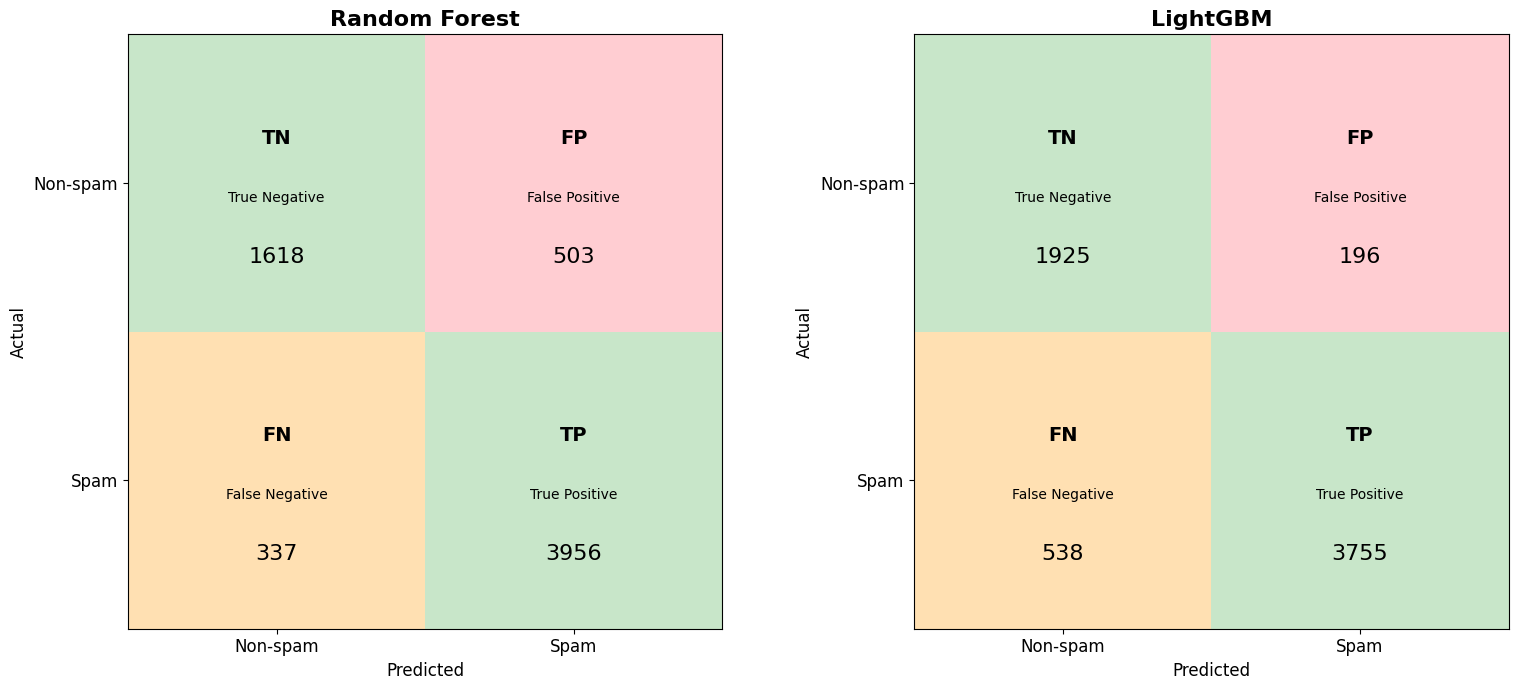

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix

# Helper function to get confusion matrix values
def get_cm_values(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp, fp, tn, fn

# Get predictions for Random Forest and LightGBM
y_pred_rf = models["RandomForest"].predict(X_test)
y_pred_xgb = models["LightGBM"].predict(X_test) # Using _xgb for LightGBM consistency

# Calculate confusion matrix values for each model
tp_rf, fp_rf, tn_rf, fn_rf = get_cm_values(y_test, y_pred_rf)
tp_xgb, fp_xgb, tn_xgb, fn_xgb = get_cm_values(y_test, y_pred_xgb)

def draw_confusion(ax, title, TP, FP, TN, FN):
    colors = {
        "TN": "#c8e6c9",   # xanh lá nhạt
        "TP": "#c8e6c9",
        "FP": "#ffcdd2",   # đỏ nhạt
        "FN": "#ffe0b2"    # cam nhạt
    }

    cells = [
        (0, 1, TN, "TN", "True Negative"),
        (1, 1, FP, "FP", "False Positive"),
        (0, 0, FN, "FN", "False Negative"),
        (1, 0, TP, "TP", "True Positive")
    ]

    for x, y, value, key, label in cells:
        rect = Rectangle((x, y), 1, 1, facecolor=colors[key])
        ax.add_patch(rect)

        ax.text(x + 0.5, y + 0.65, key,
                ha='center', va='center',
                fontsize=14, fontweight='bold')

        ax.text(x + 0.5, y + 0.45, label,
                ha='center', va='center',
                fontsize=10)

        ax.text(x + 0.5, y + 0.25, f"{value}",
                ha='center', va='center',
                fontsize=16)

    # Trục
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Non-spam", "Spam"], fontsize=12)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Spam", "Non-spam"], fontsize=12)

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)

    ax.set_title(title, fontsize=16, fontweight='bold')

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_aspect('equal')
    ax.grid(False)


# ===== VẼ 2 MODEL =====
fig, axes = plt.subplots(1, 2, figsize=(16,7))

draw_confusion(axes[0], "Random Forest", tp_rf, fp_rf, tn_rf, fn_rf)
draw_confusion(axes[1], "LightGBM", tp_xgb, fp_xgb, tn_xgb, fn_xgb)

plt.tight_layout()
plt.show()

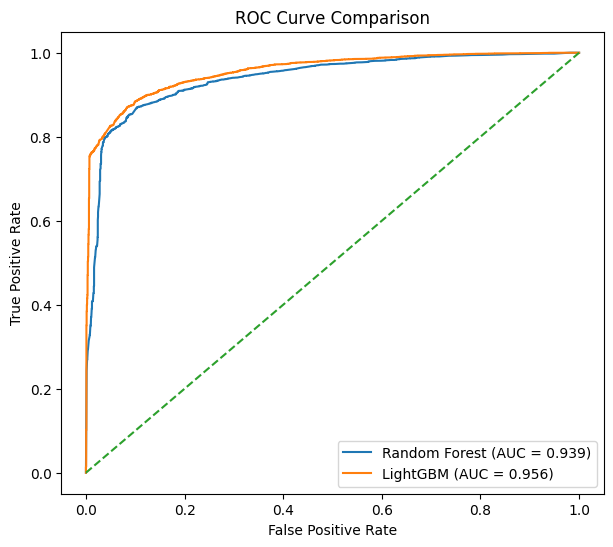

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Lấy xác suất (QUAN TRỌNG)
y_prob_rf = models["RandomForest"].predict_proba(X_test)[:,1]
y_prob_xgb = models["LightGBM"].predict_proba(X_test)[:,1]

# Tính ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# AUC
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Vẽ
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"LightGBM (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], linestyle="--")  # đường random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()



FastText
Chiều:  300  |  Accuracy: 0.7300  |  Macro F1: 0.7058
F1 Spam: 0.7902  |  F1 Non-spam: 0.6213
  Chỉ dùng embedding ngữ nghĩa

Behavioral
Chiều:   10  |  Accuracy: 0.8322  |  Macro F1: 0.8265
F1 Spam: 0.8580  |  F1 Non-spam: 0.7950
  Chỉ dùng đặc trưng hành vi

Full (Proposed)
Chiều:  310  |  Accuracy: 0.8856  |  Macro F1: 0.8754
F1 Spam: 0.9110  |  F1 Non-spam: 0.8399
  Cấu hình của nghiên cứu này
BẢNG TỔNG HỢP
       Cấu hình  Chiều  Accuracy  Macro F1  F1 Spam  F1 Non-spam
       FastText    300    0.7300    0.7058   0.7902       0.6213
     Behavioral     10    0.8322    0.8265   0.8580       0.7950
Full (Proposed)    310    0.8856    0.8754   0.9110       0.8399


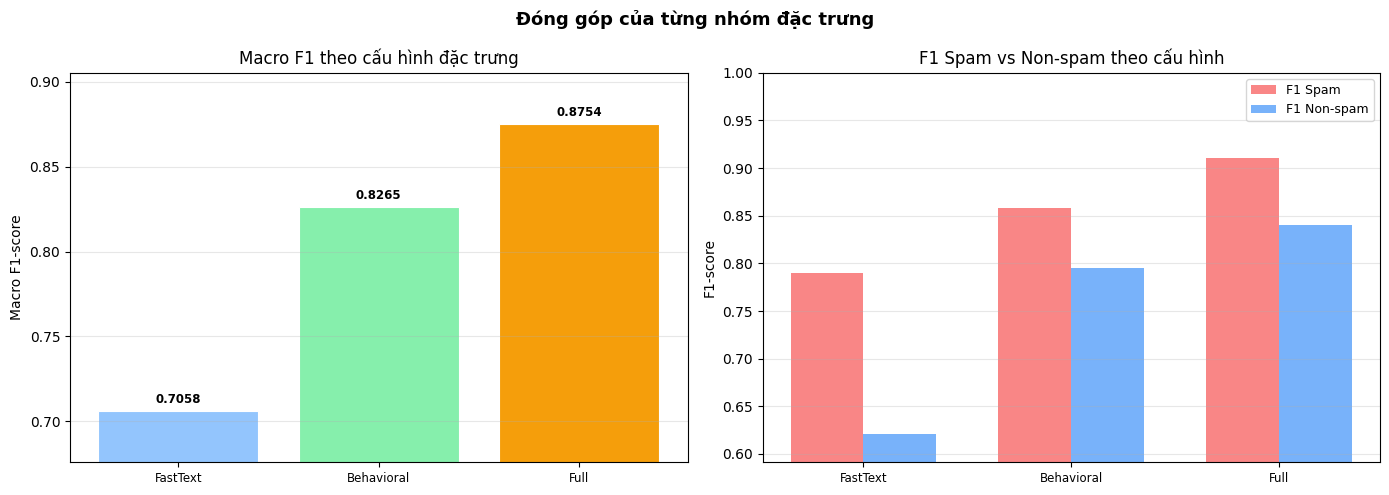

In [ ]:
# So sánh 3 cấu hình đặc trưng
# Mục đích: chứng minh mỗi nhóm đặc trưng đóng góp vào hiệu suất
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score, classification_report

# Dùng cùng model tốt nhất (best_model_name)
def make_model():
    if best_model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            class_weight="balanced", random_state=42,
            n_jobs=-1, verbose=-1
        )
    return RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1
    )

# Lấy embedding text và numeric cho train/test
_X_text_train = X_text_labeled[train_pos]
_X_text_test  = X_text_labeled[test_pos]
_X_num_train  = X_num_train   # đã StandardScaler
_X_num_test   = X_num_test

# ─Định nghĩa 5 cấu hình thử nghiệm
configs = {
    "FastText": {
        "X_tr": _X_text_train,
        "X_te": _X_text_test,
        "desc": "Chỉ dùng embedding ngữ nghĩa"
    },
    "Behavioral": {
        "X_tr": _X_num_train,
        "X_te": _X_num_test,
        "desc": "Chỉ dùng đặc trưng hành vi"
    },
    "Full (Proposed)": {
        "X_tr": np.hstack([_X_text_train, _X_num_train]),
        "X_te": np.hstack([_X_text_test,  _X_num_test]),
        "desc": "Cấu hình của nghiên cứu này"
    },
}

ablation_results = []

for config_name, cfg in configs.items():
    m = make_model()
    m.fit(cfg["X_tr"], y_train_init)
    preds = m.predict(cfg["X_te"])

    acc       = (preds == y_test).mean()
    f1_macro  = f1_score(y_test, preds, average="macro")
    f1_spam   = f1_score(y_test, preds, pos_label=1)
    f1_nospam = f1_score(y_test, preds, pos_label=0)

    ablation_results.append({
        "Cấu hình":        config_name,
        "Chiều":           cfg["X_tr"].shape[1],
        "Accuracy":        round(acc, 4),
        "Macro F1":        round(f1_macro, 4),
        "F1 Spam":         round(f1_spam, 4),
        "F1 Non-spam":     round(f1_nospam, 4),
        "Mô tả":           cfg["desc"],
    })

    marker = "NGHIÊN CỨU NÀY" if "310" in config_name else ""
    print(f"\n{config_name.replace(chr(10), ' ')}{marker}")
    print(f"Chiều: {cfg['X_tr'].shape[1]:>4}  |  Accuracy: {acc:.4f}  |  Macro F1: {f1_macro:.4f}")
    print(f"F1 Spam: {f1_spam:.4f}  |  F1 Non-spam: {f1_nospam:.4f}")
    print(f"  {cfg['desc']}")

# Bảng tổng hợp
ablation_df = pd.DataFrame(ablation_results)
print("BẢNG TỔNG HỢP")
print(ablation_df[["Cấu hình", "Chiều", "Accuracy", "Macro F1", "F1 Spam", "F1 Non-spam"]].to_string(index=False))

# Lưu bảng
# ablation_df.to_csv(root_path + "ablation_study.csv", index=False)
# print("\nĐã lưu: ablation_study.csv")

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Đóng góp của từng nhóm đặc trưng", fontsize=13, fontweight="bold")

short_names = [r["Cấu hình"].split("(")[0].strip() for r in ablation_results]
macro_f1s = [r["Macro F1"]   for r in ablation_results]
f1_spams = [r["F1 Spam"]    for r in ablation_results]
f1_nospams = [r["F1 Non-spam"] for r in ablation_results]
colors = ["#93C5FD", "#86EFAC", "#F59E0B", "#FCA5A5", "#C4B5FD"]
highlight = ["#2563EB" if "310" in r["Cấu hình"] else c for r, c in zip(ablation_results, colors)]

# Biểu đồ 1: Macro F1
bars = axes[0].bar(range(len(short_names)), macro_f1s, color=highlight, edgecolor="white", linewidth=0.8)
axes[0].set_xticks(range(len(short_names)))
axes[0].set_xticklabels(short_names, fontsize=8.5)
axes[0].set_ylabel("Macro F1-score")
axes[0].set_title("Macro F1 theo cấu hình đặc trưng")
axes[0].set_ylim(min(macro_f1s) - 0.03, max(macro_f1s) + 0.03)
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, macro_f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

# Biểu đồ 2: F1 Spam vs Non-spam grouped
x = range(len(short_names))
w = 0.35
axes[1].bar([i - w/2 for i in x], f1_spams, width=w, label="F1 Spam", color="#F87171", alpha=0.85)
axes[1].bar([i + w/2 for i in x], f1_nospams, width=w, label="F1 Non-spam", color="#60A5FA", alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(short_names, fontsize=8.5)
axes[1].set_ylabel("F1-score")
axes[1].set_title("F1 Spam vs Non-spam theo cấu hình")
axes[1].set_ylim(min(f1_spams + f1_nospams) - 0.03, 1.0)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
#plt.savefig(root_path + "ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Đã lưu biểu đồ: ablation_study.png")

### 6. Chuẩn bị dữ liệu unlabeled

#### 6.1. Tạo FastText embedding cho unlabeled data

In [ ]:
unlabeled_df["content_text"] = unlabeled_df["content_text"].fillna("").astype(str)

X_text_unlabeled = np.vstack(
    unlabeled_df["content_text"].progress_apply(get_fasttext_embedding).values
)
print(f"Embedding unlabeled shape: {X_text_unlabeled.shape}")

# Đặc trưng số (dùng scaler đã fit trên labeled train)
X_num_unlabeled = scaler.transform(
    unlabeled_df[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
)

# Kết hợp → dense numpy array (310 chiều)
X_unlabeled_full = np.hstack([X_text_unlabeled, X_num_unlabeled])

# Khởi tạo lại X_train_current từ labeled train
X_train_current = X_train_init.copy()
y_train_current = y_train_init.copy()

# Phân phối xác suất (để chọn threshold phù hợp)
print("\nPhân phối xác suất")
proba_debug = base_model.predict_proba(X_unlabeled_full)[:, 1]
print(pd.Series(proba_debug).describe())
print(f"% mẫu > 0.85: {(proba_debug > 0.85).mean():.4f} ({(proba_debug > 0.85).sum()} mẫu)")
print(f"% mẫu < 0.15: {(proba_debug < 0.15).mean():.4f} ({(proba_debug < 0.15).sum()} mẫu)")
print(f"% mẫu > 0.90: {(proba_debug > 0.90).mean():.4f} ({(proba_debug > 0.90).sum()} mẫu)")
print(f"% mẫu < 0.10: {(proba_debug < 0.10).mean():.4f} ({(proba_debug < 0.10).sum()} mẫu)")
print(f"% mẫu > 0.95: {(proba_debug > 0.95).mean():.4f} ({(proba_debug > 0.95).sum()} mẫu)")
print(f"% mẫu < 0.05: {(proba_debug < 0.05).mean():.4f} ({(proba_debug < 0.05).sum()} mẫu)")


  0%|          | 0/288614 [00:00<?, ?it/s]

Embedding unlabeled shape: (288614, 300)

Phân phối xác suất
count    288614.000000
mean          0.356623
std           0.364141
min           0.000558
25%           0.038203
50%           0.186393
75%           0.642222
max           0.999987
dtype: float64
% mẫu > 0.85: 0.1766 (50955 mẫu)
% mẫu < 0.15: 0.4649 (134182 mẫu)
% mẫu > 0.90: 0.1645 (47489 mẫu)
% mẫu < 0.10: 0.3996 (115343 mẫu)
% mẫu > 0.95: 0.1535 (44304 mẫu)
% mẫu < 0.05: 0.2907 (83896 mẫu)


#### 6.2. Tham số cấu hình pseudo-labeling

In [ ]:
BASE_THRESHOLD_HIGH = 0.95
BASE_THRESHOLD_LOW  = 0.05
DECAY        = 0.01
MIN_THRESHOLD = 0.80
MAX_ITER     = 20
BASE_TOP_K   = 1500
MAX_TOP_K    = 15000

remaining_indices = np.arange(X_unlabeled_full.shape[0])
history   = []
current_model  = base_model
best_f1   = 0
best_model_state = None
patience  = 5
counter   = 0


### 7. Vòng lặp Pseudo-Labeling

In [ ]:
# Theo dõi toàn bộ pseudo-labeled samples với confidence
pseudo_records = []  # Lưu lại từng mẫu pseudo gồm index + nhãn + confidence

for iteration in range(1, MAX_ITER + 1):
    if len(remaining_indices) == 0:
        print("Đã hết dữ liệu unlabeled.")
        break

    print(f"\nVòng lặp {iteration}")

    threshold_high = max(BASE_THRESHOLD_HIGH - iteration * DECAY, MIN_THRESHOLD)
    threshold_low = min(BASE_THRESHOLD_LOW  + iteration * DECAY, 1 - MIN_THRESHOLD)
    current_top_k = min(BASE_TOP_K * iteration, MAX_TOP_K)
    print(f"Threshold: [{threshold_low:.3f}, {threshold_high:.3f}] | Top-K: {current_top_k}")

    # Predict trên phần còn lại
    proba = current_model.predict_proba(X_unlabeled_full[remaining_indices])[:, 1]

    all_spam_idx = np.where(proba > threshold_high)[0]
    all_notspam_idx = np.where(proba < threshold_low)[0]

    spam_sel = all_spam_idx[np.argsort(-proba[all_spam_idx])][:current_top_k // 2]
    notspam_sel = all_notspam_idx[np.argsort(proba[all_notspam_idx])][:current_top_k // 2]

    selected_in_remaining = np.concatenate([spam_sel, notspam_sel])

    if len(selected_in_remaining) < 1:
        print("Không còn mẫu nào đủ độ tin cậy.")
        break

    actual_indices = remaining_indices[selected_in_remaining]

    y_pseudo = np.concatenate([
        np.ones(len(spam_sel), dtype=int),
        np.zeros(len(notspam_sel), dtype=int)
    ])

    confidence_scores = np.concatenate([
        proba[spam_sel],      # xác suất spam (cao → gần 1)
        proba[notspam_sel]    # xác suất spam (thấp → gần 0, confidence non-spam)
    ])

    X_pseudo = X_unlabeled_full[actual_indices]

    X_train_current = np.vstack([X_train_current, X_pseudo])
    y_train_current = np.concatenate([y_train_current, y_pseudo])

    # Lưu record để xuất dataset sau
    for idx, label, conf, iter_n in zip(
        actual_indices, y_pseudo, confidence_scores, [iteration]*len(actual_indices)
    ):
        pseudo_records.append({
            "unlabeled_index": idx,
            "pseudo_label":    int(label),
            "confidence":      round(float(conf), 6),
            "iteration":       iter_n
        })

    remaining_indices = np.delete(remaining_indices, selected_in_remaining)

    # Khởi tạo lại model mỗi vòng
    if best_model_name == "LightGBM":
        current_model = LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            class_weight="balanced", random_state=42,
            n_jobs=-1, verbose=-1
        )
    else:
        current_model = RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=42, n_jobs=-1
        )
    current_model.fit(X_train_current, y_train_current)

    y_pred = current_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"Thêm: {len(selected_in_remaining)} mẫu (spam={len(spam_sel)}, non-spam={len(notspam_sel)}) | Còn lại: {len(remaining_indices)}")
    print(f"Test Accuracy: {acc:.4f} | Test Macro F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = current_model
        counter = 0
        print(f"Model tốt nhất mới: Macro F1 = {best_f1:.4f}")
    else:
        counter += 1
        print(f"Không cải thiện ({counter}/{patience})")
        if counter >= patience:
            print(f"Dừng sớm sau {patience} vòng không cải thiện.")
            break

    history.append({
        "iteration": iteration,
        "threshold_high": round(threshold_high, 3),
        "f1_macro": round(f1, 6),
        "added": len(selected_in_remaining),
        "spam_added": len(spam_sel),
        "notspam_added": len(notspam_sel),
        "remaining": len(remaining_indices)
    })

current_model = best_model_state if best_model_state is not None else current_model
print(f"\nBest Macro F1: {best_f1:.4f}")


Vòng lặp 1
Threshold: [0.060, 0.940] | Top-K: 1500
Thêm: 1500 mẫu (spam=750, non-spam=750) | Còn lại: 287114
Test Accuracy: 0.8856 | Test Macro F1: 0.8753
Model tốt nhất mới: Macro F1 = 0.8753

Vòng lặp 2
Threshold: [0.070, 0.930] | Top-K: 3000
Thêm: 3000 mẫu (spam=1500, non-spam=1500) | Còn lại: 284114
Test Accuracy: 0.8877 | Test Macro F1: 0.8772
Model tốt nhất mới: Macro F1 = 0.8772

Vòng lặp 3
Threshold: [0.080, 0.920] | Top-K: 4500
Thêm: 4500 mẫu (spam=2250, non-spam=2250) | Còn lại: 279614
Test Accuracy: 0.8899 | Test Macro F1: 0.8794
Model tốt nhất mới: Macro F1 = 0.8794

Vòng lặp 4
Threshold: [0.090, 0.910] | Top-K: 6000
Thêm: 6000 mẫu (spam=3000, non-spam=3000) | Còn lại: 273614
Test Accuracy: 0.8895 | Test Macro F1: 0.8784
Không cải thiện (1/5)

Vòng lặp 5
Threshold: [0.100, 0.900] | Top-K: 7500
Thêm: 7500 mẫu (spam=3750, non-spam=3750) | Còn lại: 266114
Test Accuracy: 0.8901 | Test Macro F1: 0.8789
Không cải thiện (2/5)

Vòng lặp 6
Threshold: [0.110, 0.890] | Top-K: 9000
Th

### 8. Đánh giá mô hình cuối cùng

In [ ]:
final_model  = best_model_state if best_model_state is not None else current_model
y_pred_final = final_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Accuracy: 0.8926
Macro F1: 0.8816

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      2121
           1       0.94      0.89      0.92      4293

    accuracy                           0.89      6414
   macro avg       0.87      0.89      0.88      6414
weighted avg       0.90      0.89      0.89      6414


Confusion Matrix:
[[1884  237]
 [ 452 3841]]


### 9. Lịch sử vòng lặp & biểu đồ

Lịch sử vòng lặp
 iteration  threshold_high  f1_macro  added  spam_added  notspam_added  remaining
         1            0.94  0.875301   1500         750            750     287114
         2            0.93  0.877220   3000        1500           1500     284114
         3            0.92  0.879438   4500        2250           2250     279614
         4            0.91  0.878368   6000        3000           3000     273614
         5            0.90  0.878903   7500        3750           3750     266114
         6            0.89  0.881552   9000        4500           4500     257114
         7            0.88  0.879840  10500        5250           5250     246614
         8            0.87  0.880529  12000        6000           6000     234614
         9            0.86  0.877326  13500        6750           6750     221114
        10            0.85  0.880254  15000        7500           7500     206114


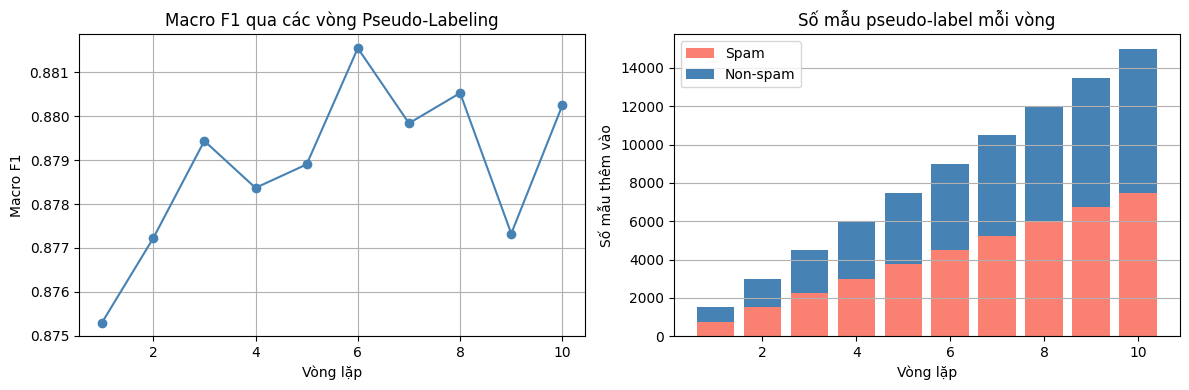

In [ ]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
print("Lịch sử vòng lặp")
print(hist_df.to_string(index=False))

if len(hist_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["iteration"], hist_df["f1_macro"], marker='o', color='steelblue')
    axes[0].set_xlabel("Vòng lặp")
    axes[0].set_ylabel("Macro F1")
    axes[0].set_title("Macro F1 qua các vòng Pseudo-Labeling")
    axes[0].grid(True)

    axes[1].bar(hist_df["iteration"], hist_df["spam_added"], label="Spam", color='salmon')
    axes[1].bar(hist_df["iteration"], hist_df["notspam_added"],
                bottom=hist_df["spam_added"], label="Non-spam", color='steelblue')
    axes[1].set_xlabel("Vòng lặp")
    axes[1].set_ylabel("Số mẫu thêm vào")
    axes[1].set_title("Số mẫu pseudo-label mỗi vòng")
    axes[1].legend()
    axes[1].grid(True, axis='y')

    plt.tight_layout()
    plt.show()


### 10. Lưu model và dữ liệu

In [ ]:
import joblib

# 1. Lưu model và scaler
joblib.dump(final_model, root_path + "Pseudo_labeling/final_pseudo_model.pkl")
joblib.dump(scaler, root_path + "Pseudo_labeling/scaler.pkl")

# 2. Xây dựng DataFrame pseudo-labeled
pseudo_df = pd.DataFrame(pseudo_records)

# Lấy metadata gốc từ unlabeled_df
pseudo_df = pseudo_df.merge(
    unlabeled_df.reset_index().rename(columns={"index": "unlabeled_index"}),
    on="unlabeled_index",
    how="left"
)

pseudo_df = pseudo_df.rename(columns={"pseudo_label": "is_spam"})
pseudo_df["label_source"] = "pseudo" # đánh dấu nguồn gốc nhãn

# 3. Xây dựng DataFrame labeled gốc (có label_source)
labeled_original = labeled_df.copy()
labeled_original["label_source"] = "manual"
labeled_original["confidence"]   = 1.0   # nhãn thủ công → confidence = 1
labeled_original["iteration"]    = 0     # vòng 0 = gán nhãn gốc

# 4. Ghép toàn bộ → full training dataset
common_cols = list(set(labeled_original.columns) & set(pseudo_df.columns))
full_df = pd.concat(
    [labeled_original[common_cols], pseudo_df[common_cols]],
    ignore_index=True
)

# 5. Lưu file

# Chỉ pseudo-labeled
pseudo_df.to_csv( root_path + "Pseudo_labeling/pseudo_labeled_only.csv",  index=False, encoding="utf-8-sig")

# Toàn bộ labeled gốc + pseudo
full_df.to_csv(  root_path + "Pseudo_labeling/full_labeled_dataset.csv",  index=False, encoding="utf-8-sig")

# Lịch sử vòng lặp
hist_df.to_csv(root_path + "Pseudo_labeling/pseudo_history.csv", index=False)